In [ ]:
!pip install -q diffusers transformers accelerate xformers safetensors \
               controlnet-aux Pillow tqdm opencv-python-headless

import torch
print("GPU:", torch.cuda.is_available())
print("GPU name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None")
print("VRAM:", round(torch.cuda.get_device_properties(0).total_memory/1e9,1), "GB" if torch.cuda.is_available() else "")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 45.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 290.4/290.4 kB 16.5 MB/s eta 0:00:00
GPU: True
GPU name: Tesla T4
VRAM: 15.6 GB


In [1]:
from google.colab import drive
drive.mount('/content/drive')
print("✅ Google Drive mounted")

Mounted at /content/drive
✅ Google Drive mounted


In [2]:
# ═══════════════════════════════════════════════════
#   EDIT ONLY THIS CELL
# ═══════════════════════════════════════════════════

INPUT_DIR  = "/content/drive/MyDrive/mast2"         # your original images
OUTPUT_DIR = "/content/drive/MyDrive/mast2_dataset"  # where dataset saves

# ── How many variants per image ──────────────────
# Damaged  : 3 ControlNet  + 3 img2img  = 6 total
# Good     : 2 ControlNet  + 2 img2img  = 4 total
N_DAMAGED_CONTROLNET = 3
N_DAMAGED_IMG2IMG    = 3
N_GOOD_CONTROLNET    = 2
N_GOOD_IMG2IMG       = 2

# ── img2img strength ─────────────────────────────
# Good (img2img): very low — stay as close to original as possible
GOOD_IMG2IMG_STRENGTH_MIN    = 0.10
GOOD_IMG2IMG_STRENGTH_MAX    = 0.20

# Damaged (img2img): medium — change surface, preserve structure
DAMAGED_IMG2IMG_STRENGTH_MIN = 0.48
DAMAGED_IMG2IMG_STRENGTH_MAX = 0.65

# ── ControlNet strength ──────────────────────────
# conditioning_scale: how hard ControlNet enforces edges (0.0–2.0)
# strength: how much to deviate from source image (0.0–1.0)
CONTROLNET_CONDITIONING_SCALE = 1.0   # edge enforcement (higher = more faithful structure)
GOOD_CONTROLNET_STRENGTH      = 0.35  # low = stay close for good condition
DAMAGED_CONTROLNET_STRENGTH_MIN = 0.50
DAMAGED_CONTROLNET_STRENGTH_MAX = 0.70

# ── Canny edge thresholds for ControlNet ─────────
CANNY_LOW  = 80
CANNY_HIGH = 200

# ── Inference settings ───────────────────────────
NUM_STEPS      = 25
GUIDANCE_SCALE = 7.5

# ═══════════════════════════════════════════════════

import os
from pathlib import Path

os.makedirs(OUTPUT_DIR, exist_ok=True)
SUPPORTED_EXT = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

if os.path.exists(INPUT_DIR):
    imgs = [f for f in os.listdir(INPUT_DIR) if Path(f).suffix.lower() in SUPPORTED_EXT]
    total_per_image = (N_DAMAGED_CONTROLNET + N_DAMAGED_IMG2IMG +
                       N_GOOD_CONTROLNET    + N_GOOD_IMG2IMG)
    print(f"✅ Config ready")
    print(f"   Input dir      : {INPUT_DIR}")
    print(f"   Output dir     : {OUTPUT_DIR}")
    print(f"   Images found   : {len(imgs)}")
    print(f"   Per image breakdown:")
    print(f"     Damaged  → {N_DAMAGED_CONTROLNET} ControlNet  + {N_DAMAGED_IMG2IMG} img2img  = {N_DAMAGED_CONTROLNET+N_DAMAGED_IMG2IMG} damaged")
    print(f"     Good     → {N_GOOD_CONTROLNET} ControlNet  + {N_GOOD_IMG2IMG} img2img  = {N_GOOD_CONTROLNET+N_GOOD_IMG2IMG} good")
    print(f"     Total per image : {total_per_image} variants")
    print(f"   Grand total    : ~{len(imgs) * total_per_image} generated images")
else:
    print(f"⚠️  INPUT_DIR not found: {INPUT_DIR}")

✅ Config ready
   Input dir      : /content/drive/MyDrive/mast2
   Output dir     : /content/drive/MyDrive/mast2_dataset
   Images found   : 31
   Per image breakdown:
     Damaged  → 3 ControlNet  + 3 img2img  = 6 damaged
     Good     → 2 ControlNet  + 2 img2img  = 4 good
     Total per image : 10 variants
   Grand total    : ~310 generated images


In [ ]:
# ═══════════════════════════════════════════════════
#   PROMPT LIBRARY (ALT VERSION)
#   Same structure, different prompt variations
# ═══════════════════════════════════════════════════

GOOD_PROMPTS = [
    "ship mast in top condition, smooth metallic surface, recently coated paint, clear horizon, natural lighting, ultra realistic maritime photo",
    "modern naval mast clean and intact, bright daylight, minimal wear, crisp details, ocean backdrop, high resolution realism",
    "well-kept ship mast with fresh coating, no visible defects, harbor setting, soft cloudy sky, documentary style maritime image",
    "marine mast structure fully intact, tight cables and fixtures, clean finish, open sea background, hyper realistic photography",
    "navigation mast spotless and functional, even lighting, no corrosion or damage, industrial maritime realism, high clarity",
]

DAMAGE_PROMPTS = [
    # Corrosion
    "ship mast with widespread oxidation, deep reddish corrosion layers eating into metal, streaking rust trails, high detail maritime decay",
    "marine mast corroded around fasteners and seams, patchy rust clusters expanding outward, advanced metal degradation, realistic texture",

    # Paint failure
    "ship mast with flaking surface coating, peeling layers exposing dull metal underneath, uneven weathered texture, realistic aging",
    "mast surface heavily faded from sun exposure, powdery and dull coating, discoloration across structure, environmental wear detail",

    # Structural
    "ship mast visibly twisted at upper section, deformation from heavy weather, distorted alignment, structural stress damage",
    "mast base showing fracture lines and weakened joints, visible cracking along welded sections, realistic mechanical failure",

    # Rigging
    "mast with snapped support cables hanging loosely, tension loss in rigging system, disorganized wires, storm aftermath realism",
    "ship mast with misaligned and knotted cables, broken mounts and loose attachments, mechanical rigging failure",

    # Environmental
    "mast covered in salt residue buildup, crusty white deposits along edges and joints, long-term ocean exposure damage",
    "ship mast heavily soiled with bird residue accumulation, layered stains across beams and fixtures, neglected condition realism",

    # Impact
    "mast showing signs of collision damage, compressed metal sections with sharp dents, impact deformation, realistic maritime accident",
    "mast with heat exposure damage, darkened burn areas and thermal discoloration patterns, electrical fault aftermath",

    # Staining
    "mast stained with dark lubricants and grime, streaks flowing downward along structure, industrial contamination realism",
]

NEGATIVE_PROMPT = (
    "cartoon style, digital art, anime style, hand-drawn, sketchy lines, watermark, "
    "overlay text, captions, blur, pixelated, bad quality, incorrect lighting, "
    "fully destroyed object, abstract mast shape, unrealistic effects, CGI look, "
    "3d modeled appearance, synthetic feel, toy-like object, scale model"
)

print(f"✅ Prompts loaded")
print(f"   Good prompts   : {len(GOOD_PROMPTS)}")
print(f"   Damage prompts : {len(DAMAGE_PROMPTS)}")

✅ Prompts loaded
   Good prompts   : 5
   Damage prompts : 13


In [ ]:
# ═══════════════════════════════════════════════════
#   LOAD PIPELINES
#   Pipeline A : SD img2img          (~4 GB download)
#   Pipeline B : SD + ControlNet Canny (~4.6 GB total)
#   Both share the same SD 1.5 weights — efficient memory use
# ═══════════════════════════════════════════════════

import torch
from diffusers import (
    StableDiffusionImg2ImgPipeline,
    StableDiffusionControlNetImg2ImgPipeline,
    ControlNetModel,
    UniPCMultistepScheduler,
)
from PIL import Image

SD_MODEL_ID         = "runwayml/stable-diffusion-v1-5"
CONTROLNET_MODEL_ID = "lllyasviel/sd-controlnet-canny"

# ── Load ControlNet model ──
print("Loading ControlNet model (canny)...")
controlnet = ControlNetModel.from_pretrained(
    CONTROLNET_MODEL_ID,
    torch_dtype=torch.float16
)

# ── Pipeline A: plain img2img ──
print("Loading SD img2img pipeline...")
pipe_img2img = StableDiffusionImg2ImgPipeline.from_pretrained(
    SD_MODEL_ID,
    torch_dtype=torch.float16,
    safety_checker=None,
    requires_safety_checker=False,
)
pipe_img2img.scheduler = UniPCMultistepScheduler.from_config(pipe_img2img.scheduler.config)
pipe_img2img = pipe_img2img.to("cuda")
pipe_img2img.enable_attention_slicing()
pipe_img2img.enable_xformers_memory_efficient_attention()
print("✅ img2img pipeline ready")

# ── Pipeline B: ControlNet img2img ──
print("Loading ControlNet img2img pipeline (reuses SD weights)...")
pipe_controlnet = StableDiffusionControlNetImg2ImgPipeline.from_pretrained(
    SD_MODEL_ID,
    controlnet=controlnet,
    torch_dtype=torch.float16,
    safety_checker=None,
    requires_safety_checker=False,
)
pipe_controlnet.scheduler = UniPCMultistepScheduler.from_config(pipe_controlnet.scheduler.config)
pipe_controlnet = pipe_controlnet.to("cuda")
pipe_controlnet.enable_attention_slicing()
pipe_controlnet.enable_xformers_memory_efficient_attention()
print("✅ ControlNet pipeline ready")

print(f"\n✅ Both pipelines loaded")
print(f"   VRAM used: {torch.cuda.memory_allocated()/1e9:.1f} GB / "
      f"{torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")

Loading ControlNet model (canny)...
Loading SD img2img pipeline...


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ img2img pipeline ready
Loading ControlNet img2img pipeline (reuses SD weights)...


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ ControlNet pipeline ready

✅ Both pipelines loaded
   VRAM used: 5.1 GB / 15.6 GB


In [ ]:
# ═══════════════════════════════════════════════════
#   CORE HELPER FUNCTIONS
# ═══════════════════════════════════════════════════

import cv2
import numpy as np
import random
import torch
from PIL import Image
from pathlib import Path


def resize_for_sd(img: Image.Image, target: int = 512) -> Image.Image:
    """
    Resize + center-crop to target x target (SD 1.5 optimal size).
    """
    w, h   = img.size
    scale  = target / min(w, h)
    new_w  = int(w * scale)
    new_h  = int(h * scale)
    img    = img.resize((new_w, new_h), Image.LANCZOS)
    left   = (new_w - target) // 2
    top    = (new_h - target) // 2
    return img.crop((left, top, left + target, top + target))


def make_canny_control_image(img: Image.Image,
                              low: int = CANNY_LOW,
                              high: int = CANNY_HIGH) -> Image.Image:
    """
    Extract Canny edges from a PIL image.
    Returns a 3-channel PIL image of edges (white lines on black).
    This is the 'control signal' that ControlNet uses to enforce structure.

    How it works:
      - Canny detects edges (structural outlines of the mast)
      - ControlNet uses these edges as a hard geometric constraint
      - So even if the prompt says 'add rust', the mast shape is preserved
    """
    img_np   = np.array(img.convert("RGB"))
    gray     = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)
    edges    = cv2.Canny(gray, low, high)
    edges_3ch = np.stack([edges] * 3, axis=-1)   # replicate to 3 channels
    return Image.fromarray(edges_3ch)


# ── Generation: plain img2img ──────────────────────

def generate_img2img(
    source_img : Image.Image,
    prompt     : str,
    strength   : float,
    seed       : int = None,
) -> Image.Image:
    """
    SD img2img — anchors output to source image via 'strength'.
    Low strength = stays close to input structure/colour.
    Used for: good variants (strength 0.10–0.20), damaged variants (0.48–0.65)
    """
    if seed is None:
        seed = random.randint(0, 2**31)

    generator = torch.Generator("cuda").manual_seed(seed)

    with torch.autocast("cuda"):
        result = pipe_img2img(
            prompt              = prompt,
            negative_prompt     = NEGATIVE_PROMPT,
            image               = source_img,
            strength            = strength,
            num_inference_steps = NUM_STEPS,
            guidance_scale      = GUIDANCE_SCALE,
            generator           = generator,
            num_images_per_prompt = 1,
        )
    return result.images[0]


# ── Generation: ControlNet img2img ─────────────────

def generate_controlnet(
    source_img           : Image.Image,
    control_img          : Image.Image,   # canny edge image
    prompt               : str,
    strength             : float,
    conditioning_scale   : float = CONTROLNET_CONDITIONING_SCALE,
    seed                 : int   = None,
) -> Image.Image:
    """
    ControlNet img2img — uses Canny edges to lock the mast structure.

    Two-level control:
      1. control_image (edges) → locks geometry / shape of the mast
      2. strength              → controls how much colour/texture can change
      3. prompt                → steers appearance (rust, clean paint, etc.)

    This combination gives the best structure preservation for damaged variants.
    """
    if seed is None:
        seed = random.randint(0, 2**31)

    generator = torch.Generator("cuda").manual_seed(seed)

    with torch.autocast("cuda"):
        result = pipe_controlnet(
            prompt                   = prompt,
            negative_prompt          = NEGATIVE_PROMPT,
            image                    = source_img,      # init image
            control_image            = control_img,     # edge map
            strength                 = strength,
            controlnet_conditioning_scale = conditioning_scale,
            num_inference_steps      = NUM_STEPS,
            guidance_scale           = GUIDANCE_SCALE,
            generator                = generator,
            num_images_per_prompt    = 1,
        )
    return result.images[0]


print("✅ Core functions ready")

✅ Core functions ready


In [ ]:
# ═══════════════════════════════════════════════════
#   PER-IMAGE PROCESSING FUNCTION
#
#   For each source mast image generates:
#
#   GOOD CONDITION (4 total):
#     good_cn_01.jpg  ← ControlNet  (edge-locked, low strength)
#     good_cn_02.jpg  ← ControlNet
#     good_i2i_01.jpg ← img2img     (strength 0.10–0.20)
#     good_i2i_02.jpg ← img2img
#
#   DAMAGED (6 total):
#     damaged_cn_01.jpg  ← ControlNet  (edge-locked, medium strength)
#     damaged_cn_02.jpg  ← ControlNet
#     damaged_cn_03.jpg  ← ControlNet
#     damaged_i2i_01.jpg ← img2img     (strength 0.48–0.65)
#     damaged_i2i_02.jpg ← img2img
#     damaged_i2i_03.jpg ← img2img
# ═══════════════════════════════════════════════════

import torch
from pathlib import Path
import random


def process_one_mast(image_path: Path, image_id: str, output_dir: str):

    img_out = Path(output_dir) / image_id
    img_out.mkdir(parents=True, exist_ok=True)

    # ── Load & prepare source ──────────────────────
    try:
        src     = Image.open(image_path).convert("RGB")
        src_512 = resize_for_sd(src, target=512)
    except Exception as e:
        print(f"  ❌ Cannot open {image_path.name}: {e}")
        return

    # Save original
    src_512.save(img_out / "original.jpg", quality=95)

    # Pre-compute canny edge map once (reused for all ControlNet calls)
    control_img = make_canny_control_image(src_512, low=CANNY_LOW, high=CANNY_HIGH)
    control_img.save(img_out / "canny_edges.jpg", quality=90)   # save for reference

    # ════════════════════════════════════════════════
    #   GOOD — CONTROLNET  (2 images)
    # ════════════════════════════════════════════════
    good_pool = random.sample(GOOD_PROMPTS, min(
        N_GOOD_CONTROLNET + N_GOOD_IMG2IMG, len(GOOD_PROMPTS)
    ))
    good_cn_prompts   = good_pool[:N_GOOD_CONTROLNET]
    good_i2i_prompts  = good_pool[N_GOOD_CONTROLNET:N_GOOD_CONTROLNET + N_GOOD_IMG2IMG]

    for i, prompt in enumerate(good_cn_prompts, 1):
        out_path = img_out / f"good_cn_{i:02d}.jpg"
        if out_path.exists():
            print(f"    ↩ Skipping {out_path.name}")
            continue
        seed = random.randint(0, 2**31)
        print(f"    🟢 [ControlNet] good_cn_{i:02d}  strength={GOOD_CONTROLNET_STRENGTH:.2f}  seed={seed}")
        try:
            img = generate_controlnet(
                source_img         = src_512,
                control_img        = control_img,
                prompt             = prompt,
                strength           = GOOD_CONTROLNET_STRENGTH,
                conditioning_scale = CONTROLNET_CONDITIONING_SCALE,
                seed               = seed,
            )
            img.save(out_path, quality=95)
        except Exception as e:
            print(f"    ❌ {out_path.name} failed: {e}")

    # ════════════════════════════════════════════════
    #   GOOD — IMG2IMG  (2 images, strength 0.10–0.20)
    # ════════════════════════════════════════════════
    for i, prompt in enumerate(good_i2i_prompts, 1):
        out_path = img_out / f"good_i2i_{i:02d}.jpg"
        if out_path.exists():
            print(f"    ↩ Skipping {out_path.name}")
            continue
        strength = random.uniform(GOOD_IMG2IMG_STRENGTH_MIN, GOOD_IMG2IMG_STRENGTH_MAX)
        seed     = random.randint(0, 2**31)
        print(f"    🟢 [img2img]    good_i2i_{i:02d}  strength={strength:.2f}  seed={seed}")
        try:
            img = generate_img2img(src_512, prompt, strength=strength, seed=seed)
            img.save(out_path, quality=95)
        except Exception as e:
            print(f"    ❌ {out_path.name} failed: {e}")

    # ════════════════════════════════════════════════
    #   DAMAGED — CONTROLNET  (3 images)
    # ════════════════════════════════════════════════
    damage_pool = random.sample(DAMAGE_PROMPTS, min(
        N_DAMAGED_CONTROLNET + N_DAMAGED_IMG2IMG, len(DAMAGE_PROMPTS)
    ))
    dmg_cn_prompts  = damage_pool[:N_DAMAGED_CONTROLNET]
    dmg_i2i_prompts = damage_pool[N_DAMAGED_CONTROLNET:N_DAMAGED_CONTROLNET + N_DAMAGED_IMG2IMG]

    for i, prompt in enumerate(dmg_cn_prompts, 1):
        out_path = img_out / f"damaged_cn_{i:02d}.jpg"
        if out_path.exists():
            print(f"    ↩ Skipping {out_path.name}")
            continue
        strength = random.uniform(DAMAGED_CONTROLNET_STRENGTH_MIN, DAMAGED_CONTROLNET_STRENGTH_MAX)
        seed     = random.randint(0, 2**31)
        print(f"    🔴 [ControlNet] damaged_cn_{i:02d}  strength={strength:.2f}  seed={seed}")
        try:
            img = generate_controlnet(
                source_img         = src_512,
                control_img        = control_img,
                prompt             = prompt,
                strength           = strength,
                conditioning_scale = CONTROLNET_CONDITIONING_SCALE,
                seed               = seed,
            )
            img.save(out_path, quality=95)
        except Exception as e:
            print(f"    ❌ {out_path.name} failed: {e}")

    # ════════════════════════════════════════════════
    #   DAMAGED — IMG2IMG  (3 images)
    # ════════════════════════════════════════════════
    for i, prompt in enumerate(dmg_i2i_prompts, 1):
        out_path = img_out / f"damaged_i2i_{i:02d}.jpg"
        if out_path.exists():
            print(f"    ↩ Skipping {out_path.name}")
            continue
        strength = random.uniform(DAMAGED_IMG2IMG_STRENGTH_MIN, DAMAGED_IMG2IMG_STRENGTH_MAX)
        seed     = random.randint(0, 2**31)
        print(f"    🔴 [img2img]    damaged_i2i_{i:02d}  strength={strength:.2f}  seed={seed}")
        try:
            img = generate_img2img(src_512, prompt, strength=strength, seed=seed)
            img.save(out_path, quality=95)
        except Exception as e:
            print(f"    ❌ {out_path.name} failed: {e}")

    total = len(list(img_out.glob("*.jpg")))
    print(f"  ✅ {image_id} done — {total} files saved (incl. original + edge map)\n")


print("✅ process_one_mast() ready")

✅ process_one_mast() ready


In [ ]:
# ═══════════════════════════════════════════════════
#   RUN FULL BATCH — safe to re-run (resumes from last stop)
#   Expected time: ~90–120 min for 37 images on T4 GPU
# ═══════════════════════════════════════════════════

from tqdm.notebook import tqdm
import json

image_paths = sorted([
    p for p in Path(INPUT_DIR).iterdir()
    if p.suffix.lower() in SUPPORTED_EXT
])

if not image_paths:
    print(f"❌ No images found in {INPUT_DIR}")
else:
    expected_per_image = (
        1                          # original
        + N_GOOD_CONTROLNET        # good_cn_*.jpg
        + N_GOOD_IMG2IMG           # good_i2i_*.jpg
        + N_DAMAGED_CONTROLNET     # damaged_cn_*.jpg
        + N_DAMAGED_IMG2IMG        # damaged_i2i_*.jpg
        + 1                        # canny_edges.jpg
    )

    print(f"🚀 Starting batch")
    print(f"   Source images : {len(image_paths)}")
    print(f"   Per image     : {expected_per_image} files")
    print(f"   Grand total   : ~{len(image_paths) * expected_per_image} files")
    print(f"   Output        : {OUTPUT_DIR}")
    print("=" * 55)

    # Save config
    json.dump({
        "n_good_controlnet"   : N_GOOD_CONTROLNET,
        "n_good_img2img"      : N_GOOD_IMG2IMG,
        "n_damaged_controlnet": N_DAMAGED_CONTROLNET,
        "n_damaged_img2img"   : N_DAMAGED_IMG2IMG,
        "sd_model"            : SD_MODEL_ID,
        "controlnet_model"    : CONTROLNET_MODEL_ID,
        "total_source"        : len(image_paths),
    }, open(Path(OUTPUT_DIR) / "run_config.json", "w"), indent=2)

    for idx, img_path in enumerate(tqdm(image_paths, desc="Mast images")):
        image_id = f"mast_{idx+1:03d}"
        img_out  = Path(OUTPUT_DIR) / image_id

        # Resume check
        if img_out.exists():
            done = len(list(img_out.glob("*.jpg")))
            if done >= expected_per_image:
                print(f"[{idx+1:02d}/{len(image_paths)}] ↩ {image_id} complete ({done} files). Skipping.")
                continue

        print(f"\n[{idx+1:02d}/{len(image_paths)}] 📷  {img_path.name}  →  {image_id}")
        process_one_mast(img_path, image_id, OUTPUT_DIR)

        # Free GPU memory between images
        torch.cuda.empty_cache()

    print("\n" + "=" * 55)
    print("🎉 Batch complete!")

🚀 Starting batch
   Source images : 31
   Per image     : 12 files
   Grand total   : ~372 files
   Output        : /content/drive/MyDrive/mast2_dataset


Mast images:   0%|          | 0/31 [00:00<?, ?it/s]


[01/31] 📷  1.jpg  →  mast_001
    🟢 [ControlNet] good_cn_01  strength=0.35  seed=573745094


  0%|          | 0/8 [00:00<?, ?it/s]

    🟢 [ControlNet] good_cn_02  strength=0.35  seed=388085937


...

    🔴 [img2img]    damaged_i2i_02  strength=0.64  seed=593916849


  0%|          | 0/16 [00:00<?, ?it/s]

    🔴 [img2img]    damaged_i2i_03  strength=0.51  seed=35784300


  0%|          | 0/12 [00:00<?, ?it/s]

  ✅ mast_031 done — 12 files saved (incl. original + edge map)


🎉 Batch complete!


In [ ]:
# ═══════════════════════════════════════════════════
#   DATASET STATISTICS
# ═══════════════════════════════════════════════════

mast_dirs = sorted([d for d in Path(OUTPUT_DIR).iterdir() if d.is_dir()])

t_orig = t_gcn = t_gi2i = t_dcn = t_di2i = 0
incomplete = []

for d in mast_dirs:
    orig  = len(list(d.glob("original.jpg")))
    gcn   = len(list(d.glob("good_cn_*.jpg")))
    gi2i  = len(list(d.glob("good_i2i_*.jpg")))
    dcn   = len(list(d.glob("damaged_cn_*.jpg")))
    di2i  = len(list(d.glob("damaged_i2i_*.jpg")))
    t_orig  += orig
    t_gcn   += gcn
    t_gi2i  += gi2i
    t_dcn   += dcn
    t_di2i  += di2i
    if (gcn < N_GOOD_CONTROLNET or gi2i < N_GOOD_IMG2IMG or
        dcn < N_DAMAGED_CONTROLNET or di2i < N_DAMAGED_IMG2IMG):
        incomplete.append((d.name, gcn, gi2i, dcn, di2i))

total = t_orig + t_gcn + t_gi2i + t_dcn + t_di2i

print("=" * 52)
print("  DATASET SUMMARY")
print("=" * 52)
print(f"  Mast groups              : {len(mast_dirs)}")
print(f"  Originals                : {t_orig}")
print(f"  Good   — ControlNet      : {t_gcn}  (target {len(mast_dirs)*N_GOOD_CONTROLNET})")
print(f"  Good   — img2img         : {t_gi2i}  (target {len(mast_dirs)*N_GOOD_IMG2IMG})")
print(f"  Damaged — ControlNet     : {t_dcn}  (target {len(mast_dirs)*N_DAMAGED_CONTROLNET})")
print(f"  Damaged — img2img        : {t_di2i}  (target {len(mast_dirs)*N_DAMAGED_IMG2IMG})")
print(f"  ─────────────────────────────────────")
print(f"  TOTAL images             : {total}")
print("=" * 52)

if incomplete:
    print(f"\n⚠️  {len(incomplete)} incomplete groups (re-run Cell 8 to fix):")
    print(f"   {'Name':<12} {'gcn':>5} {'gi2i':>6} {'dcn':>5} {'di2i':>6}")
    for name, gcn, gi2i, dcn, di2i in incomplete:
        print(f"   {name:<12} {gcn:>5}/{N_GOOD_CONTROLNET} {gi2i:>5}/{N_GOOD_IMG2IMG} {dcn:>5}/{N_DAMAGED_CONTROLNET} {di2i:>5}/{N_DAMAGED_IMG2IMG}")
else:
    print("✅ All groups complete!")

  DATASET SUMMARY
  Mast groups              : 31
  Originals                : 31
  Good   — ControlNet      : 62  (target 62)
  Good   — img2img         : 62  (target 62)
  Damaged — ControlNet     : 93  (target 93)
  Damaged — img2img        : 93  (target 93)
  ─────────────────────────────────────
  TOTAL images             : 341
✅ All groups complete!


/tmp/ipykernel_2016/2155341779.py:52: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2016/2155341779.py:52: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2016/2155341779.py:52: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2016/2155341779.py:54: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=100, bbox_inches="tight")
/tmp/ipykernel_2016/2155341779.py:54: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=100, bbox_inches="tight")
/tmp/ipykernel_2016/2155341779.py:54: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=100, bbox_inches="tight")
/usr/local/lib/python3.12/dist-packages/

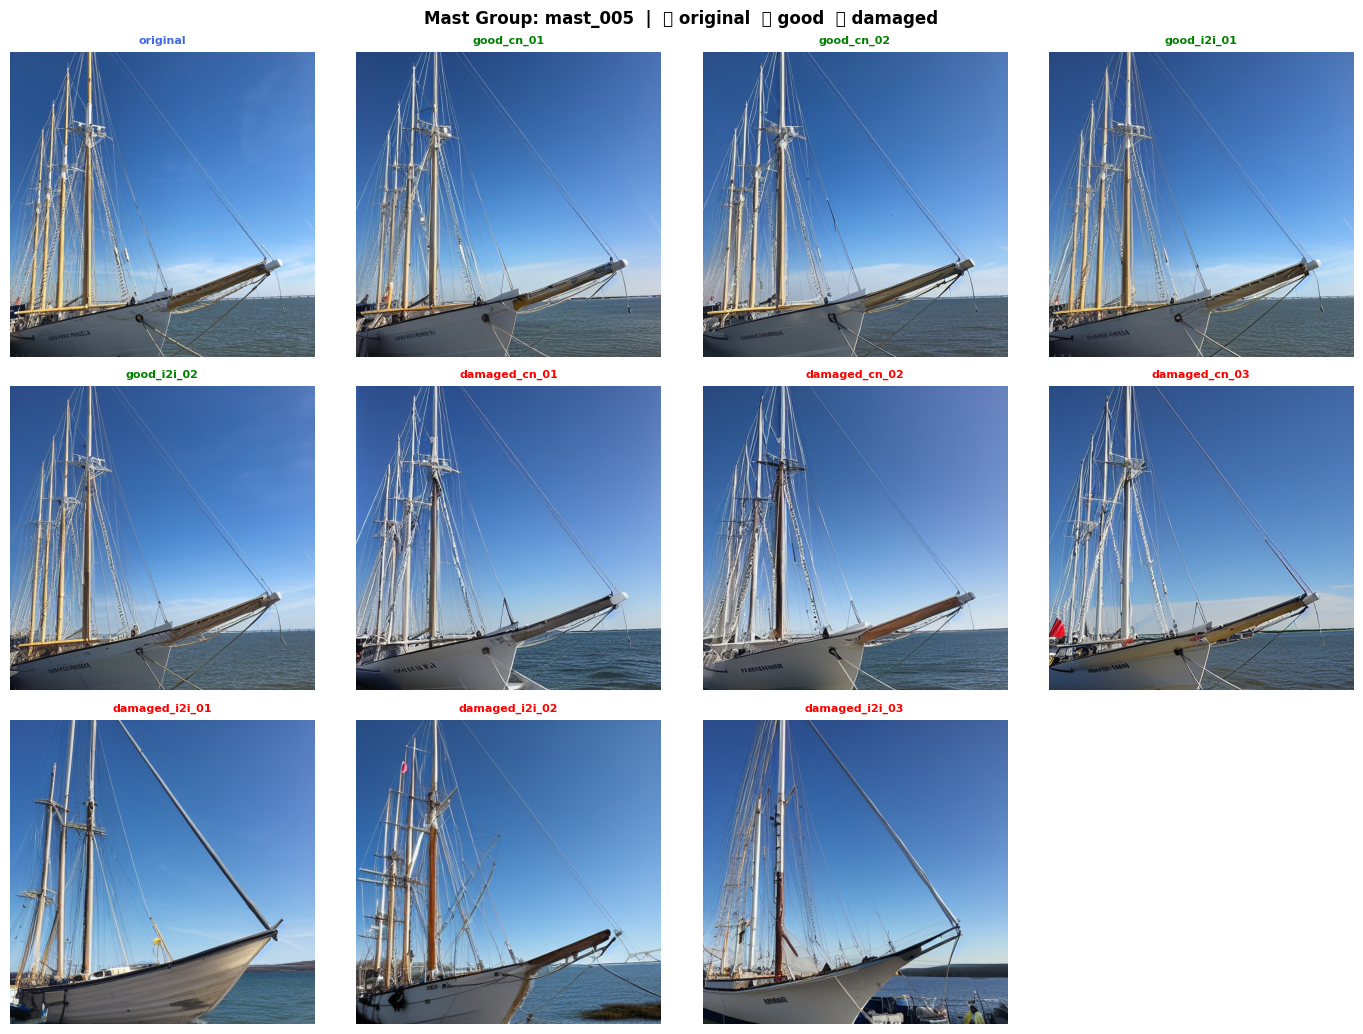

Preview saved → /content/drive/MyDrive/mast2_dataset/mast_005_preview.jpg


In [7]:
# ═══════════════════════════════════════════════════
#   VISUAL PREVIEW — shows all variants for one mast
#   Change mast_id below to inspect any group
# ═══════════════════════════════════════════════════

import matplotlib.pyplot as plt
import matplotlib.image as mpimg

mast_id = "mast_005"   # ← change this

mast_dir = Path(OUTPUT_DIR) / mast_id

sections = {
    "original"  : [mast_dir / "original.jpg"],
    "good (CN)" : sorted(mast_dir.glob("good_cn_*.jpg")),
    "good (i2i)": sorted(mast_dir.glob("good_i2i_*.jpg")),
    "damaged (CN)" : sorted(mast_dir.glob("damaged_cn_*.jpg")),
    "damaged (i2i)": sorted(mast_dir.glob("damaged_i2i_*.jpg")),
}

all_imgs    = []
all_labels  = []
all_colours = []

for section_name, paths in sections.items():
    for p in paths:
        if p.exists():
            all_imgs.append(p)
            all_labels.append(p.stem)
            if "damaged" in section_name:
                all_colours.append("red")
            elif "good" in section_name:
                all_colours.append("green")
            else:
                all_colours.append("royalblue")

cols = 4
rows = (len(all_imgs) + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(cols * 3.5, rows * 3.5))
axes = axes.flatten()

for ax, p, label, color in zip(axes, all_imgs, all_labels, all_colours):
    ax.imshow(mpimg.imread(str(p)))
    ax.set_title(label, color=color, fontsize=8, fontweight="bold")
    ax.axis("off")

for ax in axes[len(all_imgs):]:
    ax.set_visible(False)

plt.suptitle(f"Mast Group: {mast_id}  |  🔵 original  🟢 good  🔴 damaged",
             fontsize=12, fontweight="bold")
plt.tight_layout()
save_path = Path(OUTPUT_DIR) / f"{mast_id}_preview.jpg"
plt.savefig(save_path, dpi=100, bbox_inches="tight")
plt.show()
print(f"Preview saved → {save_path}")